## Co z tym dalej robić, czyli inferencja i optymalizacja

Nasz model wydaje się działać całkiem nieźle, ale na razie jedynym obserwowalnym wynikiem jest procentowa liczba błędów. Tym razem spróbujemy dowiedzieć się, jak możemy wykorzystać nasz model, jak poprawić jego skuteczność oraz stworzymy swój własny model, który potrafi odróżniać inne rzeczy niż orły i kury.

Zaczniemy od załadowania modelu, który wytrenowaliśmy na poprzedniej lekcji:

In [21]:
from fastai.vision.all import *

In [100]:
path = Path('.')
all_images = []
for dirname in ["orzel", "bocian", "kura", "kogut"]:
    all_images += get_image_files(dirname)

def what_bird(fname): return fname.parent.name
dls = ImageDataLoaders.from_path_func(
    path, all_images, valid_pct=0.2, seed=42,
    label_func=what_bird, item_tfms=Resize(224))

In [101]:
learn = cnn_learner(dls, resnet34, metrics=error_rate)
learn.load('initial-model')

### Usuwanie błędnych zdjęć

Ostatnio zauważyliśmy, że nasz zbiór zdjęć zawiera całkiem sporo błędów. Wszystkich zdjęć mamy ponad 2000, więc ręcznie sprawdzanie każdego z nich wymagałoby bardzo dużo pracy. Na szczęście nawet nasz niedoskonały model może nam w tym pomóc.

Dla każdego zdjęcia możemy wyznaczyć nie tylko jego etykietę (klasę), ale również liczbę z zakresu [0,1], która określa jak bardzo, według modelu, dane zdjęcie odpowiada każdej z klas. Jeśli wyznaczymy te wartości dla każdego zdjęcia i posortujemy, to możemy szybko znaleźć błędnie oznaczone zdjęcia (UWAGA: przed przejściem do następnej kategorii trzeba uruchomić komórkę poniżej i wykasować zdjęcia):

In [174]:
from fastai.vision.widgets import *
cleaner = ImageClassifierCleaner(learn)
cleaner

Możemy dość szybko: wyrzucić rysunki, maskotki, zabawki, latawce, tatuarze oraz rozstrzygnąć wszystkie kury i koguty bez konieczności przeglądania wszystkich 2000 zdjęć. Czasami ekspercka wiedza o drobiu może okazać się bardziej istotna niż umiejętnośi programistyczne, więc warto mieć kogoś kto pomoże rozstrzygnać trudniejsze przypadki.

Następnie usuwamy i przenosimy do odpowiednich folderów wszystkie pliki:

In [179]:
for idx in cleaner.delete(): cleaner.fns[idx].unlink()
for idx,cat in cleaner.change():
    try:
        shutil.move(str(cleaner.fns[idx]), path/cat)
    except:
        cleaner.fns[idx].unlink()

Jeśli błedów było dużo, to możemy jeszzcze raz załadować dane i nauczyć nowy model (który powinien radzić sobie lepiej), a potem wrócić do czyszczenia. Nie zapomnijmy o czyszczeniu również zbioru walidacyjnego, bo tylko wtedy mamy szanse prawidłowo ocenić sprawność naszej sieci.

In [180]:
path = Path('.')
all_images = []
for dirname in ["orzel", "bocian", "kura", "kogut"]:
    all_images += get_image_files(dirname)

def what_bird(fname): return fname.parent.name
dls = ImageDataLoaders.from_path_func(
    path, all_images, valid_pct=0.2, seed=42,
    label_func=what_bird, item_tfms=Resize(224))

learn = cnn_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.117949,0.252746,0.090909,00:13


epoch,train_loss,valid_loss,error_rate,time
0,0.283745,0.197742,0.066434,00:13
1,0.199608,0.196486,0.062937,00:13
2,0.132972,0.185160,0.045455,00:13


In [181]:
len(all_images)

1432

In [182]:
learn.save('fixed-model')

Path('models/fixed-model.pth')

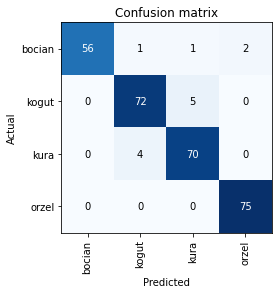

In [183]:
interp = ClassificationInterpretation.from_learner(learn, ds_idx=1)
interp.plot_confusion_matrix()

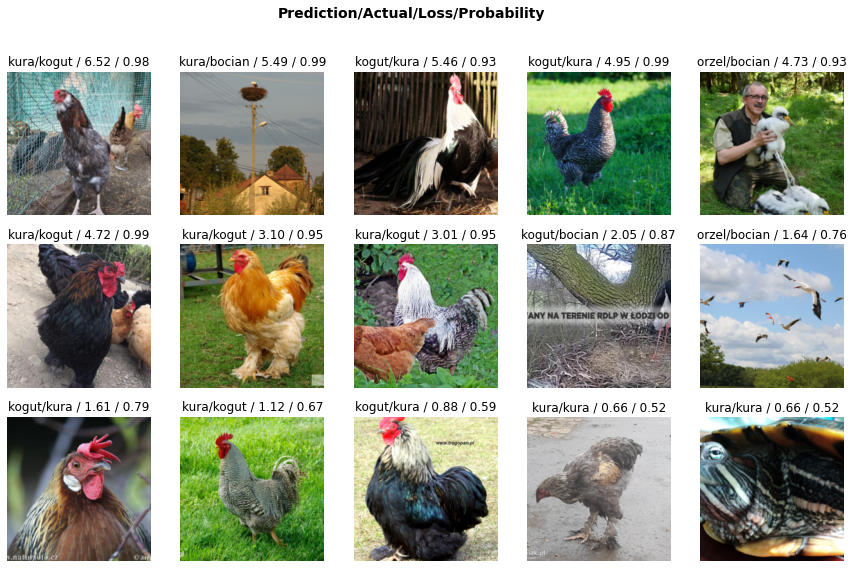

In [184]:
interp.plot_top_losses(15, nrows=3)

### Sprawdźmy, jak to działa

Możemy stworzyć mechanizm do wgrywania plików:

In [193]:
btn_upload = widgets.FileUpload()
btn_upload

FileUpload(value={}, description='Upload')

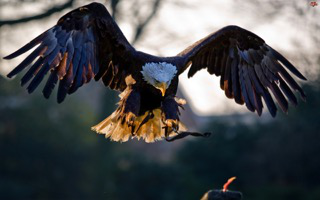

In [195]:
img = PILImage.create(btn_upload.data[-1]); img

In [196]:
learn.predict(img)

('orzel', tensor(3), tensor([4.8794e-05, 2.8476e-06, 4.2620e-07, 9.9995e-01]))

Teraz wybierz swoje własne hasła i stwórz na ich bazie klasyfikator.